# Notebook 06: Parallel Execution, Subgraphs, and Map-Reduce Patterns

## Learning Objectives

1. Implement parallel execution with the Send API
2. Create subgraphs for modularity
3. Build multi-agent architectures
4. Use map-reduce patterns
5. Implement deferred nodes (LangGraph 1.1.9 feature)

## Prerequisites

- Completed Notebooks 01-05
- Understanding of agents, tools, and state management

## 1. Introduction to Parallel Execution

### Why Parallel Execution?

Process multiple items simultaneously:
- 🚀 **Faster execution** - Don't wait for sequential processing
- 📊 **Batch operations** - Handle multiple requests at once
- 🔄 **Map-reduce workflows** - Process and aggregate results

### The Send API

```python
from langgraph.types import Send

# Instead of returning a node name, return Send objects:
return [Send("process_item", {"item": item}) for item in items]
```

This creates **multiple parallel executions** of the same node!

In [1]:
import os
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import operator

load_dotenv()
print("✅ Ready for parallel execution!")

✅ Ready for parallel execution!


## 2. Example 1: Parallel Data Processor

Process multiple items in parallel using the Send API.

In [12]:
class BatchState(TypedDict):
    items: list  # Items to process
    results: Annotated[list, operator.add]  # Results accumulate

class ItemState(TypedDict):
    item: str  # Single item

def distribute_work(state: BatchState):
    """Distribute items for parallel processing."""
    print(f"📦 Distributing {len(state['items'])} items for processing")
    return [Send("process_item", {"item": item}) for item in state["items"]]

def process_item(state: ItemState) -> dict:
    """Process a single item."""
    item = state["item"]
    print(f"  ⚙️  Processing: {item}")
    result = f"Processed: {item.upper()}"
    return {"results": [result]}

# Build parallel processing graph
parallel_graph = StateGraph(BatchState)
parallel_graph.add_node("process_item", process_item)

# distribute_work goes here as the conditional edge function, not a node
parallel_graph.add_conditional_edges(START, distribute_work, ["process_item"])
parallel_graph.add_edge("process_item", END)

parallel_app = parallel_graph.compile()

# Test parallel processing
result = parallel_app.invoke({
    "items": ["apple", "banana", "cherry", "date"],
    "results": []
})

print("\n📊 Results:")
for r in result["results"]:
    print(f"  • {r}")

📦 Distributing 4 items for processing
  ⚙️  Processing: apple
  ⚙️  Processing: banana
  ⚙️  Processing: cherry
  ⚙️  Processing: date

📊 Results:
  • Processed: APPLE
  • Processed: BANANA
  • Processed: CHERRY
  • Processed: DATE


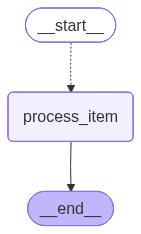

In [13]:
from IPython.display import Image, display

try:
    display(Image(parallel_app.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(parallel_app.get_graph().draw_mermaid())

In [18]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# ── Two-level state design ────────────────────────────────
# OverallState: the global shared state of the whole graph
# WorkerState:  the private state injected per Send() call

class OverallState(TypedDict):
    documents:  list[str]           # input: list of docs to review
    reviews:   Annotated[list[str], operator.add]  # reducer: collects all results
    summary:   str

class WorkerState(TypedDict):
    document:  str   # ← each worker gets ONE document (not the full list)
    doc_index: int   # ← worker also knows which doc it is

# ── Nodes ─────────────────────────────────────────────────
def load_documents(state: OverallState):
    """Entry node: loads 4 documents into global state."""
    docs = [
        "Q4 Revenue Report: revenue up 18% YoY",
        "Risk Assessment: supply chain risks identified",
        "Product Roadmap: 3 major features planned for H1",
        "HR Update: headcount grew by 15 in Q4",
    ]
    print(f"📂 Loaded {len(docs)} documents.")
    return {"documents": docs}

def review_document(state: WorkerState):
    """
    Worker node — receives ONE document via Send().
    Note: 'state' here is WorkerState, NOT OverallState.
    Each parallel invocation of this node has a different 'document'.
    """
    doc   = state["document"]
    idx   = state["doc_index"]
    review = f"[Doc {idx+1}] ✅ Reviewed: {doc[:40]}..."
    print(f"  🔎 Worker {idx+1} reviewing doc...")
    return {"reviews": [review]}  # → appended to OverallState.reviews via reducer

def compile_summary(state: OverallState):
    """Fan-in node: receives all reviews merged by the reducer."""
    print(f"\n📝 All {len(state['reviews'])} reviews collected. Compiling summary...")
    summary = "SUMMARY: " + " | ".join(state["reviews"])
    return {"summary": summary}

# ── The KEY function: returns a list of Send() objects ────
def dispatch_reviewers(state: OverallState) -> list[Send]:
    """
    Called as a conditional edge function.
    Returns N Send objects → spawns N parallel review_document workers,
    each with its OWN custom state dict (different document + index).
    """
    return [
        Send("review_document", {"document": doc, "doc_index": i})
        for i, doc in enumerate(state["documents"])
    ]
    # Result: 4 parallel invocations of review_document, each with different doc

# ── Build Graph ───────────────────────────────────────────
builder = StateGraph(OverallState)
builder.add_node("load_documents",   load_documents)
builder.add_node("review_document",   review_document)
builder.add_node("compile_summary",   compile_summary)
builder.add_edge(START,               "load_documents")

# ← dispatch_reviewers returns [Send(...), Send(...), ...]
builder.add_conditional_edges("load_documents", dispatch_reviewers, ["review_document"])
builder.add_edge("review_document",   "compile_summary")
builder.add_edge("compile_summary",   END)
graph = builder.compile()

result = graph.invoke({"documents": [], "reviews": [], "summary": ""})
print(f"\n✅ Final summary:\n{result['summary']}")

📂 Loaded 4 documents.
  🔎 Worker 1 reviewing doc...
  🔎 Worker 2 reviewing doc...
  🔎 Worker 3 reviewing doc...
  🔎 Worker 4 reviewing doc...

📝 All 4 reviews collected. Compiling summary...

✅ Final summary:
SUMMARY: [Doc 1] ✅ Reviewed: Q4 Revenue Report: revenue up 18% YoY... | [Doc 2] ✅ Reviewed: Risk Assessment: supply chain risks iden... | [Doc 3] ✅ Reviewed: Product Roadmap: 3 major features planne... | [Doc 4] ✅ Reviewed: HR Update: headcount grew by 15 in Q4...


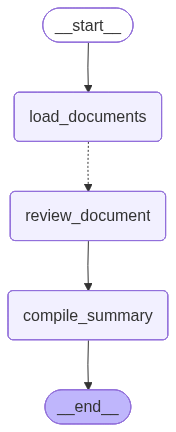

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(graph.get_graph().draw_mermaid())

## 3. Subgraphs for Multi-Agent Systems

Subgraphs allow you to create modular, reusable workflows.

### Pattern:
```
Parent Graph:
  START → coordinator → [Subgraph 1, Subgraph 2] → aggregator → END

Subgraph 1:
  entry → process → exit

Subgraph 2:
  entry → analyze → exit
```

In [19]:
# Define a reusable subgraph for an agent
class AgentState(TypedDict):
    task: str
    result: str

def researcher_node(state: AgentState) -> dict:
    """Research agent subgraph."""
    task = state["task"]
    print(f"🔍 Researcher working on: {task}")
    return {"result": f"Research findings for: {task}"}

def analyzer_node(state: AgentState) -> dict:
    """Analyzer agent subgraph."""
    task = state["task"]
    print(f"📊 Analyzer working on: {task}")
    return {"result": f"Analysis of: {task}"}

# Build subgraphs
researcher_graph = StateGraph(AgentState)
researcher_graph.add_node("research", researcher_node)
researcher_graph.add_edge(START, "research")
researcher_graph.add_edge("research", END)
researcher_subgraph = researcher_graph.compile()

analyzer_graph = StateGraph(AgentState)
analyzer_graph.add_node("analyze", analyzer_node)
analyzer_graph.add_edge(START, "analyze")
analyzer_graph.add_edge("analyze", END)
analyzer_subgraph = analyzer_graph.compile()

print("✅ Subgraphs created!")

✅ Subgraphs created!


In [24]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ── Subgraph A: Preprocessing Pipeline ────────────────────
# Has its own isolated state with private keys
class PreprocState(TypedDict):
    text:      str   # shared with parent
    char_count:int   # private — only inside subgraph A

def clean_text(state: PreprocState):
    cleaned = state["text"].strip().lower()
    print(f"  [SubA] clean_text: '{cleaned[:30]}...'")
    return {"text": cleaned}

def count_chars(state: PreprocState):
    n = len(state["text"])
    print(f"  [SubA] count_chars: {n} chars")
    return {"char_count": n}

preproc_builder = StateGraph(PreprocState)
preproc_builder.add_node("clean_text",  clean_text)
preproc_builder.add_node("count_chars", count_chars)
preproc_builder.add_edge(START,          "clean_text")
preproc_builder.add_edge("clean_text",  "count_chars")
preproc_builder.add_edge("count_chars", END)
preproc_subgraph = preproc_builder.compile()   # ← compiled = ready to be a node

# ── Subgraph B: Analysis Pipeline ─────────────────────────
class AnalysisState(TypedDict):
    text:      str    # shared with parent
    keywords: list[str]  # private — only inside subgraph B

def extract_keywords(state: AnalysisState):
    words    = [w for w in state["text"].split() if len(w) > 5]
    print(f"  [SubB] extract_keywords: {words[:4]}")
    return {"keywords": words}

def score_sentiment(state: AnalysisState):
    pos_words = ["great", "good", "excellent", "amazing", "fantastic"]
    score     = sum(1 for w in state["keywords"] if w in pos_words)
    label     = "positive" if score > 0 else "neutral"
    # Only 'text' is shared back to parent — 'keywords' stays private
    print(f"  [SubB] score_sentiment: {label}")
    return {"text": f"[{label.upper()}] {state['text']}"}

analysis_builder = StateGraph(AnalysisState)
analysis_builder.add_node("extract_keywords", extract_keywords)
analysis_builder.add_node("score_sentiment",  score_sentiment)
analysis_builder.add_edge(START,               "extract_keywords")
analysis_builder.add_edge("extract_keywords", "score_sentiment")
analysis_builder.add_edge("score_sentiment",  END)
analysis_subgraph = analysis_builder.compile()

# ── Parent Graph ───────────────────────────────────────────
# Uses both subgraphs as plain nodes via add_node()
class ParentState(TypedDict):
    text:   str   # shared key — subgraphs read & write this
    result: str

def format_result(state: ParentState):
    print(f"  [Parent] Formatting result.")
    return {"result": f"DONE: {state['text']}"}

parent = StateGraph(ParentState)
parent.add_node("preprocess", preproc_subgraph)    # ← subgraph as node!
parent.add_node("analyse",     analysis_subgraph)   # ← subgraph as node!
parent.add_node("format",      format_result)
parent.add_edge(START,         "preprocess")
parent.add_edge("preprocess",  "analyse")
parent.add_edge("analyse",     "format")
parent.add_edge("format",      END)
graph = parent.compile()

print("🚀 Running parent graph with 2 subgraphs...\n")
out = graph.invoke({"text": "  LangGraph is Great for building Agentic AI systems!  ", "result": ""})
print(f"\n✅ {out['result']}")

🚀 Running parent graph with 2 subgraphs...

  [SubA] clean_text: 'langgraph is great for buildin...'
  [SubA] count_chars: 51 chars
  [SubB] extract_keywords: ['langgraph', 'building', 'agentic', 'systems!']
  [SubB] score_sentiment: neutral
  [Parent] Formatting result.

✅ DONE: [NEUTRAL] langgraph is great for building agentic ai systems!


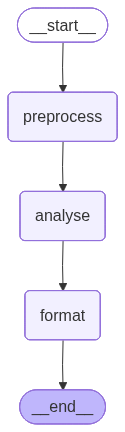

In [23]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(graph.get_graph().draw_mermaid())

## 4. Advanced Project: Multi-Agent Research System

Build a system with multiple specialized agents working together:

- **Researcher**: Gathers information
- **Analyzer**: Evaluates credibility
- **Synthesizer**: Combines findings
- **Editor**: Formats output

In [6]:
import os
from langgraph.graph.message import add_messages

class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    research_results: list
    analysis_results: list
    final_report: str

# Create specialized LLMs for each agent
researcher_llm = ChatOpenAI(model=os.getenv("OPENAI_MODEL", "openai/gpt-5.4"), temperature=0.3)
analyzer_llm = ChatOpenAI(model=os.getenv("OPENAI_MODEL", "openai/gpt-5.4"), temperature=0)
synthesizer_llm = ChatOpenAI(model=os.getenv("OPENAI_MODEL", "openai/gpt-5.4"), temperature=0.5)

# coordinator becomes a pure edge function (no node registration)
def coordinator(state: MultiAgentState):
    query = state["messages"][-1].content
    print(f"🎯 Coordinator: Distributing task: {query}")
    return [
        Send("researcher", state),
        Send("analyzer", state)
    ]

def researcher(state: MultiAgentState) -> dict:
    query = state["messages"][-1].content
    print("🔬 Researcher: Gathering information...")
    response = researcher_llm.invoke([
        HumanMessage(content=f"Research this topic and provide key facts: {query}")
    ])
    return {"research_results": [response.content]}

def analyzer(state: MultiAgentState) -> dict:
    query = state["messages"][-1].content
    print("📊 Analyzer: Evaluating sources...")
    response = analyzer_llm.invoke([
        HumanMessage(content=f"Analyze the credibility and relevance of information about: {query}")
    ])
    return {"analysis_results": [response.content]}

def synthesizer(state: MultiAgentState) -> dict:
    """Synthesize all findings into a coherent report."""
    print("✍️  Synthesizer: Creating final report...")
    
    research = "\n".join(state.get("research_results", []))
    analysis = "\n".join(state.get("analysis_results", []))
    
    response = synthesizer_llm.invoke([
        HumanMessage(content=f"Synthesize these findings into a coherent report:\n\nResearch:\n{research}\n\nAnalysis:\n{analysis}")
    ])
    
    return {"final_report": response.content}

# Build multi-agent graph
multi_agent_builder = StateGraph(MultiAgentState)
# Remove: multi_agent_builder.add_node("coordinator", coordinator)
multi_agent_builder.add_node("researcher", researcher)
multi_agent_builder.add_node("analyzer", analyzer)
multi_agent_builder.add_node("synthesizer", synthesizer)

# coordinator goes here as the edge function from START
multi_agent_builder.add_conditional_edges(START, coordinator, ["researcher", "analyzer"])
multi_agent_builder.add_edge("researcher", "synthesizer")
multi_agent_builder.add_edge("analyzer", "synthesizer")
multi_agent_builder.add_edge("synthesizer", END)

multi_agent_system = multi_agent_builder.compile()

print("✅ Multi-agent research system ready!")

✅ Multi-agent research system ready!


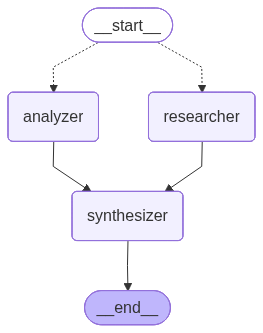

In [25]:
from IPython.display import Image, display

try:
    display(Image(multi_agent_system.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(multi_agent_system.get_graph().draw_mermaid())

In [26]:
# Test the multi-agent system
result = multi_agent_system.invoke({
    "messages": [HumanMessage(content="Explain the impact of quantum computing on cryptography")],
    "research_results": [],
    "analysis_results": [],
    "final_report": ""
})

print("\n" + "=" * 70)
print("📄 Final Research Report")
print("=" * 70)
print(result["final_report"])
print("=" * 70)

🎯 Coordinator: Distributing task: Explain the impact of quantum computing on cryptography
🔬 Researcher: Gathering information...
📊 Analyzer: Evaluating sources...
✍️  Synthesizer: Creating final report...

📄 Final Research Report
## Report: The Impact of Quantum Computing on Cryptography

Quantum computing poses a significant long-term challenge to modern cryptography, but its effects are uneven across different types of cryptographic systems. The most serious risk is to public-key cryptography, while symmetric encryption and hash functions are affected more modestly. Although current quantum computers cannot yet break widely deployed systems at scale, the threat is strategically important today because cryptographic migrations take years and adversaries may already be storing encrypted data for future decryption.

### 1. Why quantum computing is a cryptographic concern
Most widely used cryptographic systems are secure because certain mathematical problems are infeasible for classical 

In [29]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

# ── Shared state across all agents ────────────────────────
class AgentState(TypedDict):
    task:     str
    log:      Annotated[list[str], operator.add]
    result:   str

# ── Specialist Sub-Agents (each is a subgraph) ────────────

# Sub-Agent 1: Web Research Agent
class WebState(TypedDict):
    task:   str
    log:    Annotated[list[str], operator.add]
    result: str

def web_search(state: WebState):
    print("  🌐 WebAgent: searching the web...")
    return {"log": ["web_search completed"]}

def web_summarize(state: WebState):
    print("  🌐 WebAgent: summarizing results...")
    summary = f"[WEB RESULT] Found 5 sources about: {state['task']}"
    return {"result": summary, "log": ["web_summarize completed"]}

web_builder = StateGraph(WebState)
web_builder.add_node("web_search",    web_search)
web_builder.add_node("web_summarize", web_summarize)
web_builder.add_edge(START,            "web_search")
web_builder.add_edge("web_search",    "web_summarize")
web_builder.add_edge("web_summarize", END)
web_agent = web_builder.compile()

# Sub-Agent 2: Code Agent
class CodeState(TypedDict):
    task:   str
    log:    Annotated[list[str], operator.add]
    result: str

def write_code(state: CodeState):
    print("  💻 CodeAgent: writing code...")
    return {"log": ["write_code completed"]}

def test_code(state: CodeState):
    print("  💻 CodeAgent: running tests...")
    code_out = f"[CODE RESULT] Python solution for: {state['task']}"
    return {"result": code_out, "log": ["test_code completed"]}

code_builder = StateGraph(CodeState)
code_builder.add_node("write_code", write_code)
code_builder.add_node("test_code",  test_code)
code_builder.add_edge(START,        "write_code")
code_builder.add_edge("write_code", "test_code")
code_builder.add_edge("test_code",  END)
code_agent = code_builder.compile()

# ── Orchestrator Node ─────────────────────────────────────
# Reads the task, decides which specialist to route to
def orchestrator(state: AgentState) -> Command[Literal["web_agent", "code_agent"]]:
    task = state["task"].lower()
    print(f"🎯 Orchestrator received: '{state['task']}'")

    # Simple rule-based routing (would be an LLM in production)
    if "code" in task or "python" in task or "function" in task:
        print("  → Routing to CODE AGENT")
        return Command(update={"log": ["orchestrator: delegated to code_agent"]},
                       goto="code_agent")
    else:
        print("  → Routing to WEB AGENT")
        return Command(update={"log": ["orchestrator: delegated to web_agent"]},
                       goto="web_agent")

def synthesizer(state: AgentState):
    print(f"\n📋 Synthesizer received result: {state['result'][:50]}...")
    print(f"   Full log: {state['log']}")
    return {}

# ── Parent / Orchestrator Graph ────────────────────────────
builder = StateGraph(AgentState)
builder.add_node("orchestrator", orchestrator)
builder.add_node("web_agent",     web_agent)   # ← subgraph!
builder.add_node("code_agent",    code_agent)  # ← subgraph!
builder.add_node("synthesizer",   synthesizer)
builder.add_edge(START,           "orchestrator")
builder.add_edge("web_agent",     "synthesizer")
builder.add_edge("code_agent",    "synthesizer")
builder.add_edge("synthesizer",   END)
graph = builder.compile()

# ── Test both routing paths ───────────────────────────────
for task in ["Research latest AI trends in 2025",
              "Write a Python function to sort a list"]:
    print(f"\n{'='*55}\n📥 Task: {task}")
    graph.invoke({"task": task, "log": [], "result": ""})


📥 Task: Research latest AI trends in 2025
🎯 Orchestrator received: 'Research latest AI trends in 2025'
  → Routing to WEB AGENT
  🌐 WebAgent: searching the web...
  🌐 WebAgent: summarizing results...

📋 Synthesizer received result: [WEB RESULT] Found 5 sources about: Research lates...
   Full log: ['orchestrator: delegated to web_agent', 'orchestrator: delegated to web_agent', 'web_search completed', 'web_summarize completed']

📥 Task: Write a Python function to sort a list
🎯 Orchestrator received: 'Write a Python function to sort a list'
  → Routing to CODE AGENT
  💻 CodeAgent: writing code...
  💻 CodeAgent: running tests...

📋 Synthesizer received result: [CODE RESULT] Python solution for: Write a Python ...
   Full log: ['orchestrator: delegated to code_agent', 'orchestrator: delegated to code_agent', 'write_code completed', 'test_code completed']


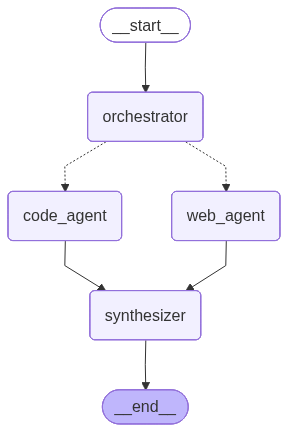

In [30]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(graph.get_graph().draw_mermaid())

## 🆕 Deferred Nodes — Race-Condition-Free Aggregation

In map-reduce patterns, there's a race condition: the aggregator node might start before all parallel branches finish. **Deferred nodes** solve this by waiting for ALL upstream parallel paths to complete before executing.

```python
graph.add_node("synthesizer", synthesize_fn, defer=True)
```

Without `defer=True`, the synthesizer might run before all researchers finish. With it, LangGraph guarantees it only runs after ALL parallel Send() executions complete.

In [9]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

class ResearchState(TypedDict):
    topics: list[str]
    findings: Annotated[list[str], operator.add]  # accumulated from parallel branches
    final_report: str

def coordinator(state: ResearchState) -> list[Send]:
    """Distribute research topics in parallel."""
    print(f"📋 Coordinating research on {len(state['topics'])} topics")
    return [Send("research_topic", {"topics": [topic], "findings": [], "final_report": ""})
            for topic in state["topics"]]

def research_topic(state: ResearchState) -> dict:
    """Research a single topic (runs in parallel)."""
    topic = state["topics"][0]
    finding = f"Research finding for '{topic}': key insight discovered"
    print(f"🔬 Researching: {topic}")
    return {"findings": [finding]}

def synthesize_report(state: ResearchState) -> dict:
    """Synthesize all findings — runs AFTER all parallel branches complete."""
    print(f"\n📊 Synthesizing {len(state['findings'])} findings...")
    findings_text = "\n".join(f"• {f}" for f in state["findings"])
    report = "FINAL REPORT:\n" + findings_text
    return {"final_report": report}

# Build graph
builder = StateGraph(ResearchState)
# Remove: builder.add_node("coordinator", coordinator)
builder.add_node("research_topic", research_topic)
builder.add_node("synthesizer", synthesize_report, defer=True)

# coordinator is the conditional edge function from START, not a node
builder.add_conditional_edges(START, coordinator, ["research_topic"])
builder.add_edge("research_topic", "synthesizer")
builder.add_edge("synthesizer", END)

app = builder.compile()

result = app.invoke({
    "topics": ["AI Safety", "Multi-Agent Systems", "LangGraph Architecture"],
    "findings": [],
    "final_report": ""
})
print(result["final_report"])

📋 Coordinating research on 3 topics
🔬 Researching: AI Safety
🔬 Researching: Multi-Agent Systems
🔬 Researching: LangGraph Architecture

📊 Synthesizing 3 findings...
FINAL REPORT:
• Research finding for 'AI Safety': key insight discovered
• Research finding for 'Multi-Agent Systems': key insight discovered
• Research finding for 'LangGraph Architecture': key insight discovered


**Why `defer=True` matters**: Without it, if topic A finishes first, `synthesizer` might run with only 1 finding. With `defer=True`, LangGraph queues the synthesizer and only executes it when ALL parallel `research_topic` branches complete — guaranteed.

## 🆕 Subgraph-to-Parent Routing with Command

Subgraphs normally can't directly influence the parent graph's routing. With `Command(graph=Command.PARENT)`, a subgraph node can break out and route within the parent graph:

In [10]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing_extensions import TypedDict

class ParentState(TypedDict):
    task: str
    escalated: bool
    result: str

class SubState(TypedDict):
    task: str
    escalated: bool
    result: str

# Subgraph with escape hatch
def process_in_subgraph(state: SubState) -> dict | Command:
    """Try to handle the task. If too complex, escalate to parent."""
    if "critical" in state["task"].lower():
        print("🚨 Subgraph: Task is critical — escalating to parent!")
        # Escape the subgraph and route in the PARENT graph
        return Command(
            goto="escalation_handler",   # node in the PARENT graph
            graph=Command.PARENT,        # ← escape to parent
            update={"escalated": True, "result": "Escalated to human review"}
        )
    
    result = f"✅ Subgraph handled: {state['task']}"
    return {"result": result}

# Build subgraph
sub_builder = StateGraph(SubState)
sub_builder.add_node("process", process_in_subgraph)
sub_builder.add_edge(START, "process")
sub_builder.add_edge("process", END)
subgraph = sub_builder.compile()

# Build parent graph
def start_task(state: ParentState) -> dict:
    print(f"🎯 Parent: Starting task '{state['task']}'" )
    return {}

def escalation_handler(state: ParentState) -> dict:
    print(f"👨‍💼 Parent: Handling escalation for '{state['task']}'" )
    return {"result": f"ESCALATED: '{state['task']}' sent to human review team"}

parent_builder = StateGraph(ParentState)
parent_builder.add_node("start", start_task)
parent_builder.add_node("subgraph_worker", subgraph)     # subgraph as node
parent_builder.add_node("escalation_handler", escalation_handler)

parent_builder.add_edge(START, "start")
parent_builder.add_edge("start", "subgraph_worker")
parent_builder.add_edge("subgraph_worker", END)
parent_builder.add_edge("escalation_handler", END)

parent_app = parent_builder.compile()

# Test 1: Normal task — handled by subgraph
print("=== Test 1: Normal task ===")
result = parent_app.invoke({"task": "process invoice", "escalated": False, "result": ""})
print(f"Result: {result['result']}")

# Test 2: Critical task — subgraph escalates to parent
print("=== Test 2: Critical task ===")
result = parent_app.invoke({"task": "CRITICAL system failure", "escalated": False, "result": ""})
print(f"Result: {result['result']}")

=== Test 1: Normal task ===
🎯 Parent: Starting task 'process invoice'
Result: ✅ Subgraph handled: process invoice
=== Test 2: Critical task ===
🎯 Parent: Starting task 'CRITICAL system failure'
🚨 Subgraph: Task is critical — escalating to parent!
👨‍💼 Parent: Handling escalation for 'CRITICAL system failure'
Result: ESCALATED: 'CRITICAL system failure' sent to human review team


## 5. Key Takeaways

### Concepts Mastered

1. **Send API**: Parallel execution of nodes
2. **Subgraphs**: Modular, reusable workflows
3. **Multi-agent systems**: Specialized agents working together
4. **Map-reduce patterns**: Distribute, process, aggregate
5. **Deferred nodes**: Wait for all parallel tasks to complete

### Best Practices

✅ **Use Send for independent tasks** - Each can run in parallel  
✅ **Design subgraphs for reusability** - DRY principle  
✅ **Coordinate agents carefully** - Clear responsibilities  
✅ **Use reducers for aggregation** - `operator.add`, etc.  

### What's Next?

In **Notebook 07**, you'll learn production-ready patterns including caching, hooks, error handling, and deployment!